# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



C:\python\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (7.1.0)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

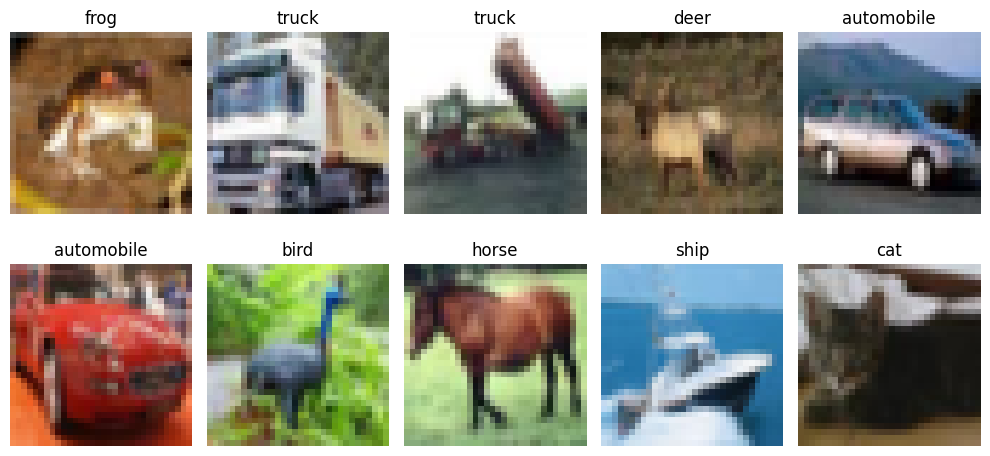

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    # TASK 1: Added extra hidden layers to increase ANN depth
    layers.Dropout(0.3),                          # Dropout after 2nd hidden layer
    layers.Dense(128, activation='relu'),         # 3rd hidden layer
    layers.Dropout(0.2),                          # Dropout after 3rd hidden layer
    layers.Dense(64, activation='relu'),          # 4th hidden layer
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Import EarlyStopping for Task 4
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# TASK 3: Increased epochs to 20 | TASK 4: Added EarlyStopping callback
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]  # TASK 4: EarlyStopping added
)

C:\python\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2102 - loss: 2.0913 - val_accuracy: 0.2850 - val_loss: 1.9551
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2766 - loss: 1.9461 - val_accuracy: 0.3066 - val_loss: 1.9020
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2909 - loss: 1.9077 - val_accuracy: 0.3098 - val_loss: 1.8749
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3070 - loss: 1.8806 - val_accuracy: 0.3422 - val_loss: 1.8242
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3158 - loss: 1.8571 - val_accuracy: 0.3364 - val_loss: 1.8369
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3201 - loss: 1.8472 - val_accuracy: 0.3668 - val_loss: 1.7929
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3270 - loss: 1.8343 - val_accuracy: 0.3656 - val_loss: 1.7920
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3294 - loss: 1.8199 - val_accura

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4002 - loss: 1.7035
ANN Test Accuracy: 0.4002000093460083


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
# TASK 2: Updated CNN filters: 32→64 (layer1), 64→128 (layer2), 128→256 (layer3)
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),  # TASK 2: 32→64
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),  # TASK 2: 64→128
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),  # TASK 2: 128→256
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TASK 4: EarlyStopping callback
from tensorflow.keras.callbacks import EarlyStopping
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# TASK 3: Increased epochs to 20 | TASK 4: Added EarlyStopping callback
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn]  # TASK 4: EarlyStopping added
)

C:\python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.4399 - loss: 1.5618 - val_accuracy: 0.4272 - val_loss: 1.8013
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.5916 - loss: 1.1758 - val_accuracy: 0.5194 - val_loss: 1.3693
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6578 - loss: 0.9931 - val_accuracy: 0.5978 - val_loss: 1.1848
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7080 - loss: 0.8430 - val_accuracy: 0.6642 - val_loss: 1.0402
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7481 - loss: 0.7323 - val_accuracy: 0.6642 - val_loss: 0.9904
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7788 - loss: 0.6439 - val_accuracy: 0.7168 - val_loss: 0.8391
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.8066 - loss: 0.5517 - val_accuracy: 0.7302 - val_loss: 0.8559
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.8330 - loss: 0.4804 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7059 - loss: 0.8922
CNN Test Accuracy: 0.7059000134468079


## 📈 Compare Learning Curves

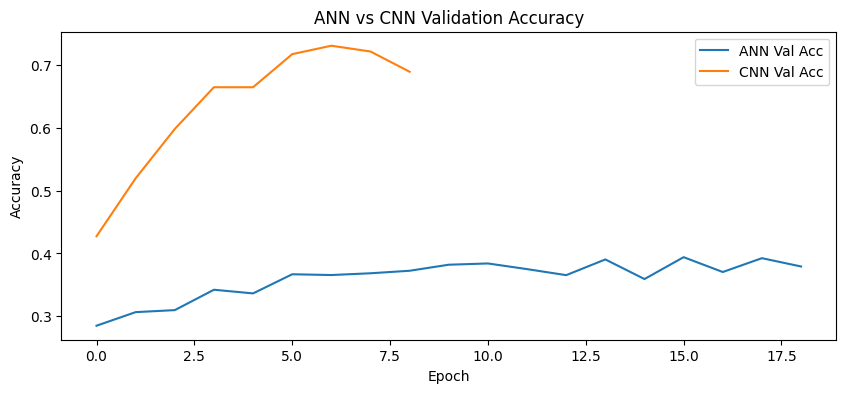

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
# Original augmentation layer approach (kept for reference)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# TASK 5: Data Augmentation Training using ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation pipeline with common transformations
aug_datagen = ImageDataGenerator(
    rotation_range=15,        # TASK 5: Random rotation up to 15 degrees
    width_shift_range=0.1,    # TASK 5: Horizontal shift
    height_shift_range=0.1,   # TASK 5: Vertical shift
    zoom_range=0.1,           # TASK 5: Random zoom
    horizontal_flip=True,     # TASK 5: Horizontal flip
    fill_mode='nearest'       # Fill empty pixels after transformation
)

# Fit the generator on training data (required for featurewise stats if used)
aug_datagen.fit(x_train_norm)

# TASK 4: EarlyStopping for augmented model
from tensorflow.keras.callbacks import EarlyStopping
early_stop_aug = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# TASK 5: Train the augmented CNN using the ImageDataGenerator
# TASK 3: Epochs set to 20
aug_history = aug_cnn_model.fit(
    aug_datagen.flow(x_train_norm, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test_norm, y_test),
    steps_per_epoch=len(x_train_norm) // 64,
    callbacks=[early_stop_aug]  # TASK 4: EarlyStopping added
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.3299 - loss: 1.8289 - val_accuracy: 0.4076 - val_loss: 1.6362
Epoch 2/20
  1/781 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4219 - loss: 1.7261

C:\python\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4219 - loss: 1.7261 - val_accuracy: 0.4177 - val_loss: 1.5903
Epoch 3/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4249 - loss: 1.5907 - val_accuracy: 0.5071 - val_loss: 1.3647
Epoch 4/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5312 - loss: 1.4412 - val_accuracy: 0.5040 - val_loss: 1.3690
Epoch 5/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.4539 - loss: 1.5153 - val_accuracy: 0.5281 - val_loss: 1.3241
Epoch 6/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4375 - loss: 1.6497 - val_accuracy: 0.5338 - val_loss: 1.2983
Epoch 7/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4756 - loss: 1.4596 - val_accuracy: 0.5407 - val_loss: 1.2911
Epoch 8/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5781 - loss: 1.3882 - val_accuracy: 0.5471 - val_loss: 1.2617
Epoch 9/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4915 - loss: 1.4313 - val_accuracy: 0.516

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]  # TASK 5: Added aug model
})
comparison

,Model,Test Accuracy
0,ANN,0.4002
1,CNN,0.7059
2,Augmented CNN,0.6033


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance: done
2. Change CNN filters from 32→64→128: done
3. Increase epochs to 20: done
4. Add **EarlyStopping** : done
5. Add **data augmentation training** : done

#  Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**